# Loan Default Prediction
## Machine Learning Classification Project
---
**Dataset :** train.csv — Credit Risk / Loan Default Dataset  
**Objective :** Predict whether a loan applicant will default (`loan_status = 1`) or not (`loan_status = 0`).  
**Models evaluated :** Logistic Regression | Random Forest | Gradient Boosting  
**Evaluation metrics :** Accuracy | Precision | Recall | F1-Score | ROC-AUC | Cross-Validation  

---
## Table of Contents
1. Imports and Configuration  
2. Dataset Loading  
3. Exploratory Data Analysis  
4. Statistical Analysis  
5. Preprocessing and Feature Engineering  
6. Correlation Analysis  
7. Model Training and Evaluation  
8. Results Analysis and Interpretation  
9. Hyperparameter Tuning  
10. Final Model and Predictions  
11. Conclusion and Recommendations  


## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score)
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize'  : (12, 7),
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'figure.dpi'      : 120,
})

PALETTE  = ['#27AE60', '#C0392B']   # 0=No Default (green), 1=Default (red)
COLORS_M = ['#2980B9', '#D35400', '#8E44AD']

print("Libraries loaded successfully.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


Libraries loaded successfully.
NumPy  : 2.0.2
Pandas : 2.2.2


## 2. Dataset Loading

### Dataset Column Reference

| Column | Type | Description |
|---|---|---|
| id | Integer | Row identifier (dropped) |
| person_age | Numerical | Applicant age |
| person_income | Numerical | Annual income |
| person_home_ownership | Categorical | RENT / MORTGAGE / OWN / OTHER |
| person_emp_length | Numerical | Employment length (years) |
| loan_intent | Categorical | Purpose of the loan |
| loan_grade | Categorical | Lender-assigned grade A–G |
| loan_amnt | Numerical | Loan amount requested |
| loan_int_rate | Numerical | Interest rate (%) |
| loan_percent_income | Numerical | Loan amount / annual income |
| cb_person_default_on_file | Categorical | Prior default on record (Y/N) |
| cb_person_cred_hist_length | Numerical | Credit history length (years) |
| **loan_status** | **Target** | **1 = Default, 0 = No Default** |


In [2]:
df = pd.read_csv('/content/train.csv')

# Drop id column — not a feature
df.drop(columns=['id'], inplace=True, errors='ignore')

print(f"Dataset loaded from: '/content/train.csv'")
print(f"Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Default rate  : {df['loan_status'].mean()*100:.1f}%  (1 = Default)")
df.head(10)

Dataset loaded from: '/content/train.csv'
Shape         : 58,645 rows x 12 columns
Default rate  : 14.2%  (1 = Default)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
5,27,45000,RENT,2.0,VENTURE,A,9000,8.94,0.20,N,5,0
6,25,45000,MORTGAGE,9.0,EDUCATION,A,12000,6.54,0.27,N,3,0
7,21,20000,RENT,0.0,PERSONAL,C,2500,13.49,0.13,Y,3,0
8,37,69600,RENT,11.0,EDUCATION,D,5000,14.84,0.07,Y,11,0
9,35,110000,MORTGAGE,0.0,DEBTCONSOLIDATION,C,15000,12.98,0.14,Y,6,0


## 3. Exploratory Data Analysis

In [3]:
print("MISSING VALUES REPORT")
print("-" * 45)
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df  = missing_df[missing_df['Count']>0].sort_values('Count', ascending=False)
if len(missing_df)==0:
    print("No missing values detected.")
else:
    print(missing_df.to_string())
print()
print("DESCRIPTIVE STATISTICS")
df[['person_age','person_income','person_emp_length',
    'loan_amnt','loan_int_rate','loan_percent_income',
    'cb_person_cred_hist_length']].describe().round(2)


MISSING VALUES REPORT
---------------------------------------------
No missing values detected.

DESCRIPTIVE STATISTICS


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,58645.00,58645.00,58645.00,58645.00,58645.00,58645.00,58645.00
mean,27.55,64046.17,4.70,9217.56,10.68,0.16,5.81
std,6.03,37931.11,3.96,5563.81,3.03,0.09,4.03
min,20.00,4200.00,0.00,500.00,5.42,0.00,2.00
25%,23.00,42000.00,2.00,5000.00,7.88,0.09,3.00
50%,26.00,58000.00,4.00,8000.00,10.75,0.14,4.00
75%,30.00,75600.00,7.00,12000.00,12.99,0.21,8.00
max,123.00,1900000.00,123.00,35000.00,23.22,0.83,30.00


In [4]:
print("CATEGORICAL DISTRIBUTIONS WITH DEFAULT RATES")
print("=" * 60)
cat_features = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']
for col in cat_features:
    print(f"{col}:")
    vc = df[col].value_counts(dropna=False)
    for val, cnt in vc.items():
        sub = df[df[col]==val]['loan_status']
        def_rate = sub.mean()*100 if len(sub)>0 else 0
        print(f"  {str(val):<20} n={cnt:>6}  ({cnt/len(df)*100:.1f}%)  default_rate={def_rate:.1f}%")
    print()


CATEGORICAL DISTRIBUTIONS WITH DEFAULT RATES
person_home_ownership:
  RENT                 n= 30594  (52.2%)  default_rate=22.3%
  MORTGAGE             n= 24824  (42.3%)  default_rate=6.0%
  OWN                  n=  3138  (5.4%)  default_rate=1.4%
  OTHER                n=    89  (0.2%)  default_rate=16.9%

loan_intent:
  EDUCATION            n= 12271  (20.9%)  default_rate=10.8%
  MEDICAL              n= 10934  (18.6%)  default_rate=17.8%
  PERSONAL             n= 10016  (17.1%)  default_rate=13.3%
  VENTURE              n= 10011  (17.1%)  default_rate=9.3%
  DEBTCONSOLIDATION    n=  9133  (15.6%)  default_rate=18.9%
  HOMEIMPROVEMENT      n=  6280  (10.7%)  default_rate=17.4%

loan_grade:
  A                    n= 20984  (35.8%)  default_rate=4.9%
  B                    n= 20400  (34.8%)  default_rate=10.2%
  C                    n= 11036  (18.8%)  default_rate=13.5%
  D                    n=  5034  (8.6%)  default_rate=59.4%
  E                    n=  1009  (1.7%)  default_rate=62.5

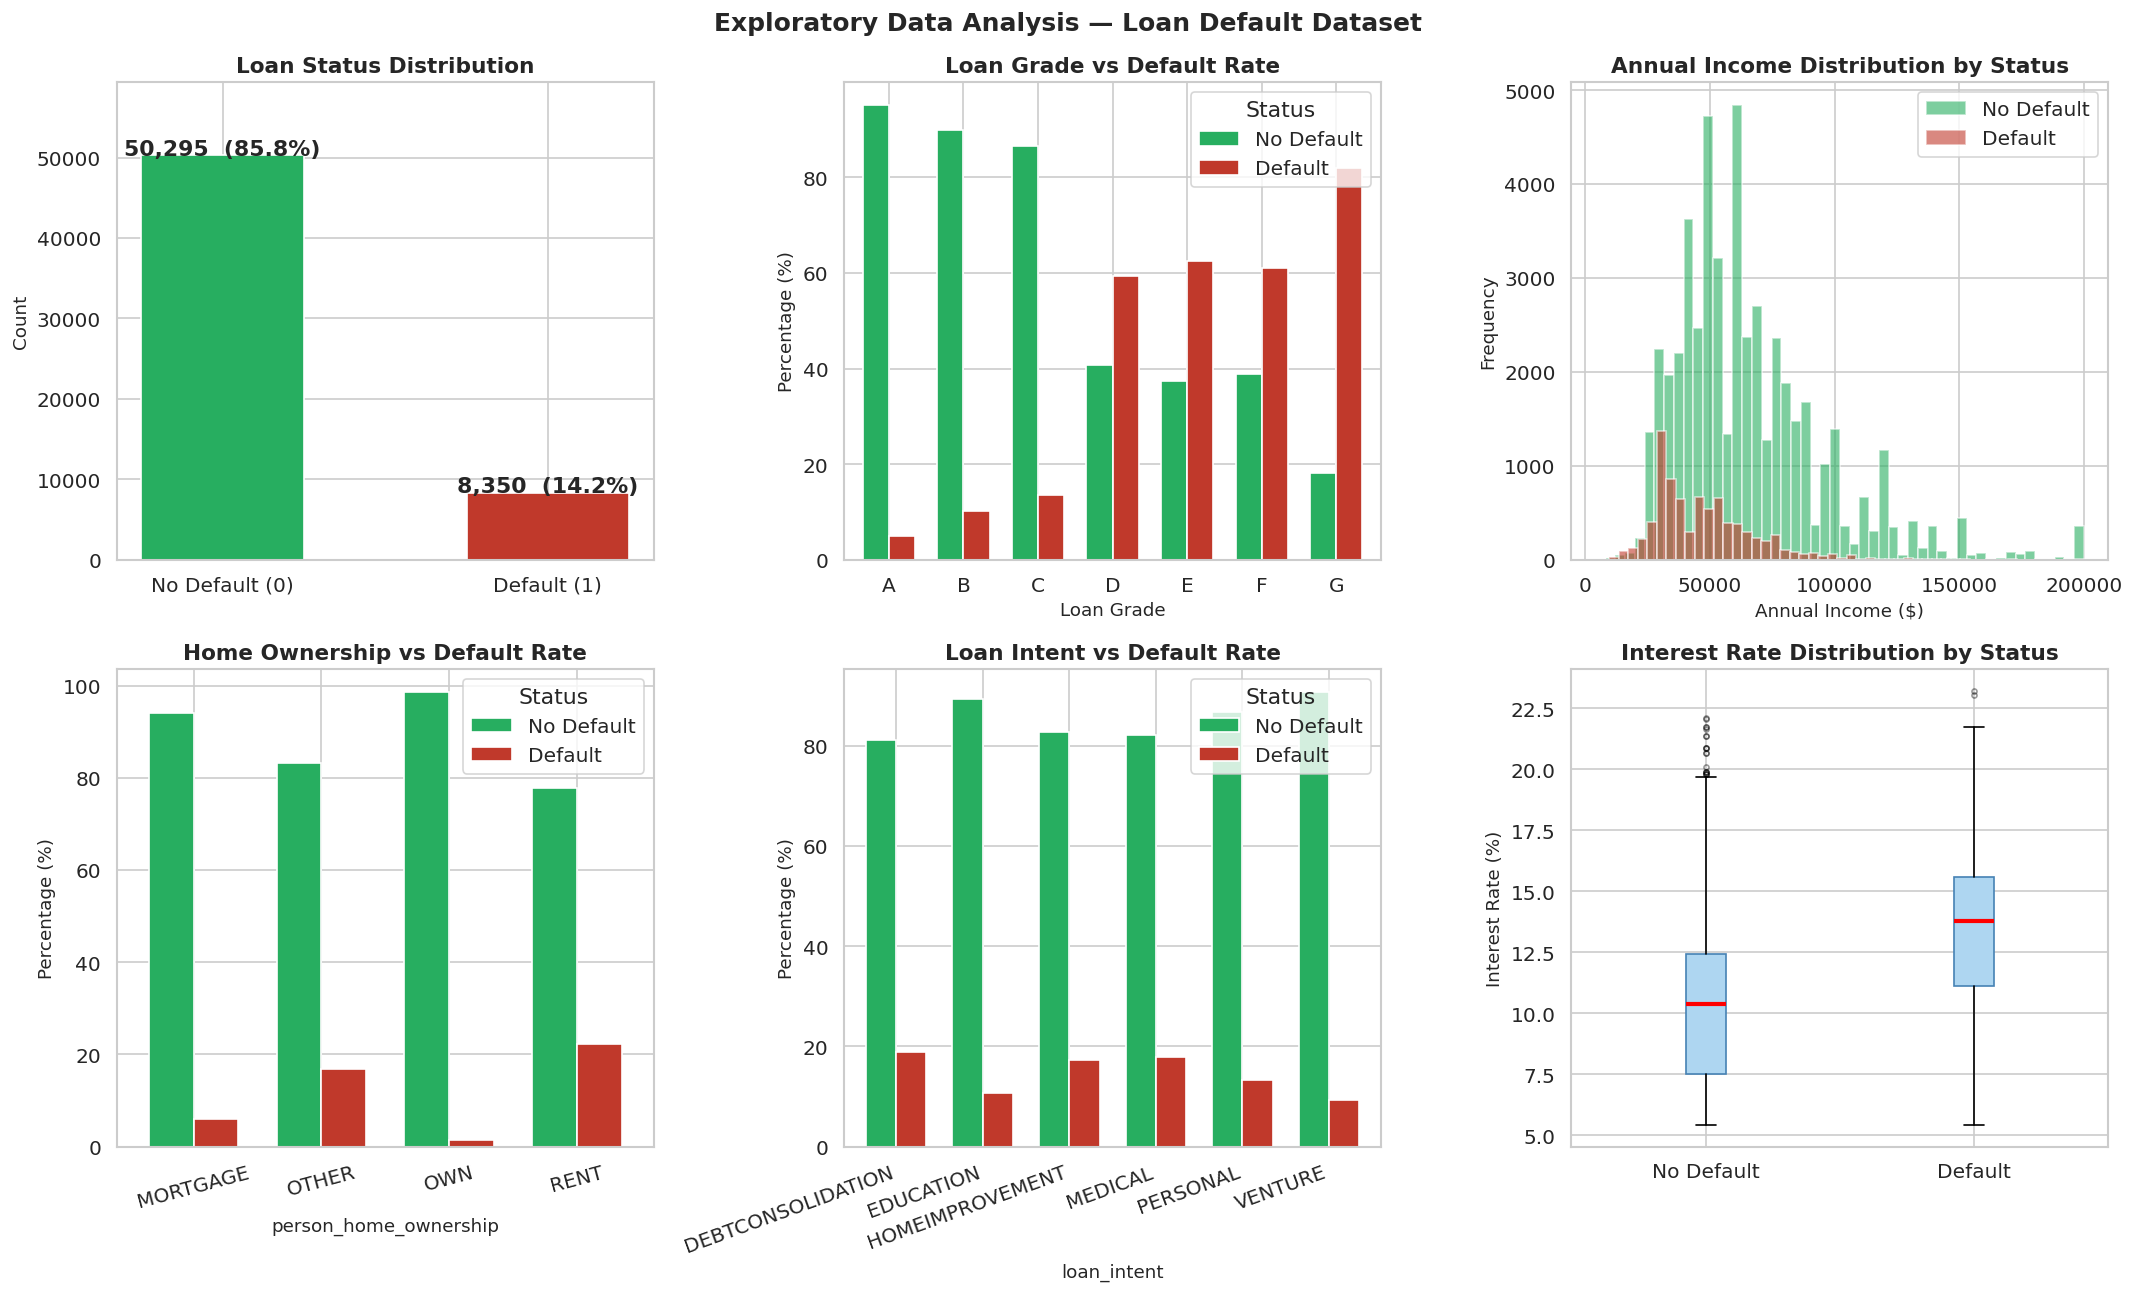

EDA overview saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Loan Default Dataset', fontsize=15, fontweight='bold')

# 1. Target distribution
counts = df['loan_status'].value_counts().sort_index()
labels = ['No Default (0)', 'Default (1)']
axes[0,0].bar(labels, counts.values, color=PALETTE, edgecolor='white', width=0.5)
for bar, val in zip(axes[0,0].patches, counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                   f'{val:,}  ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0,0].set_title('Loan Status Distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].set_ylim(0, max(counts.values)*1.18)

# 2. Loan grade vs default rate
ct = pd.crosstab(df['loan_grade'], df['loan_status'], normalize='index')*100
ct.sort_index().plot(kind='bar', ax=axes[0,1], color=PALETTE, edgecolor='white', width=0.7)
axes[0,1].set_title('Loan Grade vs Default Rate')
axes[0,1].set_xlabel('Loan Grade')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].set_xticklabels(ct.index, rotation=0)
axes[0,1].legend(['No Default','Default'], title='Status')

# 3. Income distribution by status
for status, color, label in zip([0,1], PALETTE, ['No Default','Default']):
    df[df['loan_status']==status]['person_income'].clip(upper=200000).hist(
        ax=axes[0,2], bins=50, alpha=0.6, color=color, label=label)
axes[0,2].set_title('Annual Income Distribution by Status')
axes[0,2].set_xlabel('Annual Income ($)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].legend()

# 4. Home ownership vs default
ct2 = pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index')*100
ct2.plot(kind='bar', ax=axes[1,0], color=PALETTE, edgecolor='white', width=0.7)
axes[1,0].set_title('Home Ownership vs Default Rate')
axes[1,0].set_xticklabels(ct2.index, rotation=15)
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend(['No Default','Default'], title='Status')

# 5. Loan intent vs default
ct3 = pd.crosstab(df['loan_intent'], df['loan_status'], normalize='index')*100
ct3.plot(kind='bar', ax=axes[1,1], color=PALETTE, edgecolor='white', width=0.7)
axes[1,1].set_title('Loan Intent vs Default Rate')
axes[1,1].set_xticklabels(ct3.index, rotation=20, ha='right')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].legend(['No Default','Default'], title='Status')

# 6. Interest rate boxplot
data_nd = df[df['loan_status']==0]['loan_int_rate'].dropna()
data_d  = df[df['loan_status']==1]['loan_int_rate'].dropna()
axes[1,2].boxplot([data_nd, data_d], labels=['No Default','Default'], patch_artist=True,
                  boxprops=dict(facecolor='#AED6F1', color='steelblue'),
                  medianprops=dict(color='red', linewidth=2.5),
                  flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1,2].set_title('Interest Rate Distribution by Status')
axes[1,2].set_ylabel('Interest Rate (%)')

plt.tight_layout()
plt.savefig('01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA overview saved.")


## 4. Statistical Analysis

In [6]:
print("STATISTICAL COMPARISON — Default vs Non-Default Applicants")
print("=" * 70)
num_features = ['person_age','person_income','person_emp_length',
                'loan_amnt','loan_int_rate','loan_percent_income',
                'cb_person_cred_hist_length']
for feat in num_features:
    no_def = df[df['loan_status']==0][feat].dropna()
    default = df[df['loan_status']==1][feat].dropna()
    t_stat, p_val = stats.ttest_ind(no_def, default)
    sig = "** Significant (p<0.05) **" if p_val < 0.05 else "Not significant"
    print(f"  {feat}")
    print(f"    No Default  Mean={no_def.mean():.2f}  Median={no_def.median():.2f}  Std={no_def.std():.2f}")
    print(f"    Default     Mean={default.mean():.2f}  Median={default.median():.2f}  Std={default.std():.2f}")
    print(f"    T-test: t={t_stat:.3f}  p={p_val:.4f}  {sig}")
    print()


STATISTICAL COMPARISON — Default vs Non-Default Applicants
  person_age
    No Default  Mean=27.55  Median=26.00  Std=5.98
    Default     Mean=27.53  Median=26.00  Std=6.34
    T-test: t=0.274  p=0.7844  Not significant

  person_income
    No Default  Mean=66672.87  Median=60000.00  Std=39314.38
    Default     Mean=48224.66  Median=44000.00  Std=22435.67
    T-test: t=41.765  p=0.0000  ** Significant (p<0.05) **

  person_emp_length
    No Default  Mean=4.86  Median=4.00  Std=3.95
    Default     Mean=3.73  Median=3.00  Std=3.89
    T-test: t=24.444  p=0.0000  ** Significant (p<0.05) **

  loan_amnt
    No Default  Mean=8888.88  Median=8000.00  Std=5328.36
    Default     Mean=11197.27  Median=10000.00  Std=6468.21
    T-test: t=-35.484  p=0.0000  ** Significant (p<0.05) **

  loan_int_rate
    No Default  Mean=10.26  Median=10.39  Std=2.83
    Default     Mean=13.20  Median=13.79  Std=3.02
    T-test: t=-87.245  p=0.0000  ** Significant (p<0.05) **

  loan_percent_income
    No Def

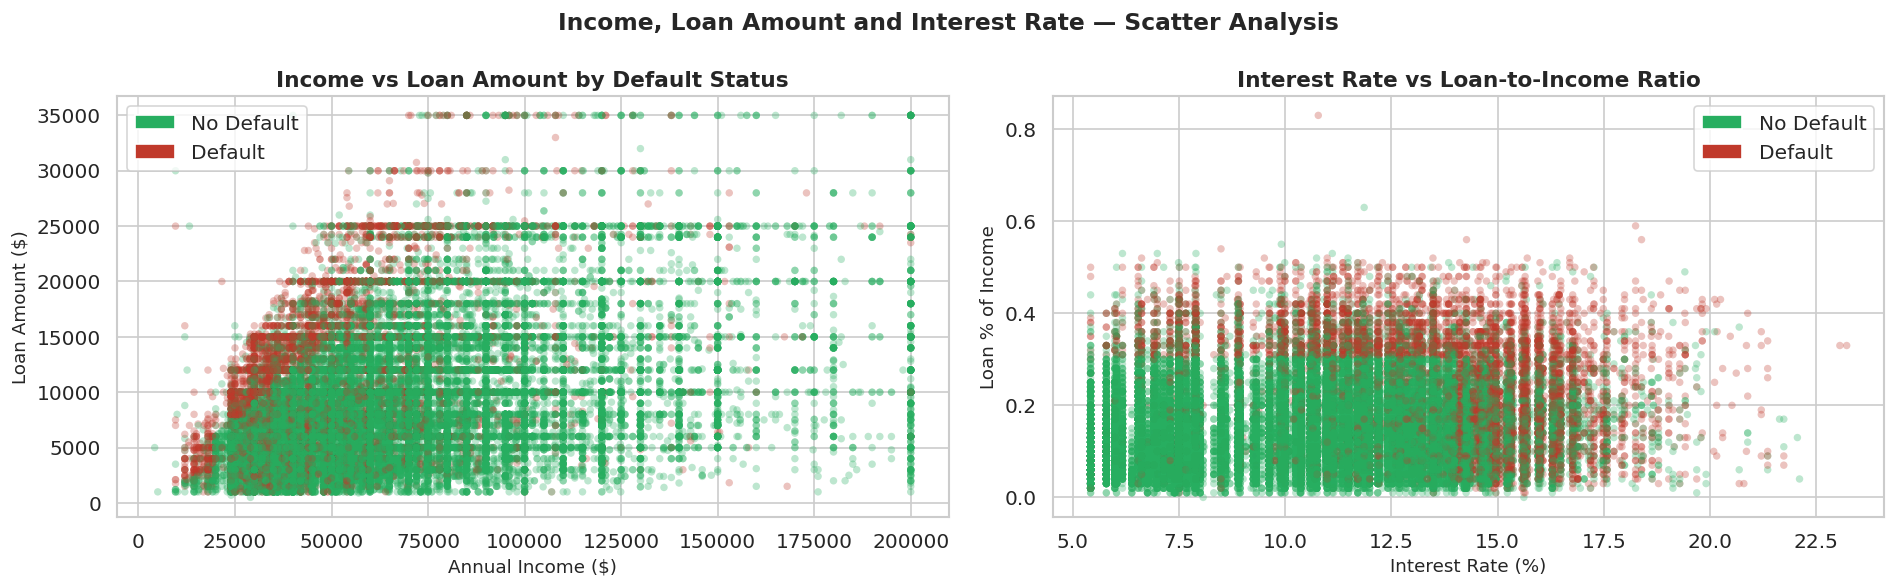

In [7]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Income, Loan Amount and Interest Rate — Scatter Analysis', fontsize=14, fontweight='bold')

color_map = df['loan_status'].map({0: PALETTE[0], 1: PALETTE[1]})

ax = axes[0]
ax.scatter(df['person_income'].clip(upper=200000), df['loan_amnt'],
           c=color_map, alpha=0.3, edgecolors='none', s=20)
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Loan Amount ($)')
ax.set_title('Income vs Loan Amount by Default Status')
ax.legend(handles=[Patch(facecolor=PALETTE[0], label='No Default'),
                   Patch(facecolor=PALETTE[1], label='Default')])

ax = axes[1]
ax.scatter(df['loan_int_rate'], df['loan_percent_income'],
           c=color_map, alpha=0.3, edgecolors='none', s=20)
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Loan % of Income')
ax.set_title('Interest Rate vs Loan-to-Income Ratio')
ax.legend(handles=[Patch(facecolor=PALETTE[0], label='No Default'),
                   Patch(facecolor=PALETTE[1], label='Default')])

plt.tight_layout()
plt.savefig('02_scatter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Preprocessing and Feature Engineering

In [8]:
df_proc = df.copy()

# ── Outlier capping (age > 90 likely data entry errors) ──
df_proc = df_proc[df_proc['person_age'] <= 90].reset_index(drop=True)
print(f"Rows after removing age outliers (>90): {len(df_proc):,}")

# ── Encode categoricals ──
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    print(f"  {col} encoded.")

# ── Handle missing values ──
num_cols = df_proc.select_dtypes(include=[np.number]).columns.tolist()
imputer  = SimpleImputer(strategy='median')
df_proc[num_cols] = imputer.fit_transform(df_proc[num_cols])

print(f"\nFinal shape after preprocessing: {df_proc.shape}")
print("\nFeature Engineering — adding derived features:")

# Derived features
df_proc['income_per_emp_year'] = df_proc['person_income'] / (df_proc['person_emp_length'] + 1)
df_proc['loan_to_income']      = df_proc['loan_amnt'] / (df_proc['person_income'] + 1)
df_proc['rate_times_pct']      = df_proc['loan_int_rate'] * df_proc['loan_percent_income']
print("  income_per_emp_year, loan_to_income, rate_times_pct added.")

df_proc.head()


Rows after removing age outliers (>90): 58,644
  person_home_ownership encoded.
  loan_intent encoded.
  loan_grade encoded.
  cb_person_default_on_file encoded.

Final shape after preprocessing: (58644, 12)

Feature Engineering — adding derived features:
  income_per_emp_year, loan_to_income, rate_times_pct added.


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,income_per_emp_year,loan_to_income,rate_times_pct
0,37.0,35000.0,3.0,0.0,1.0,1.0,6000.0,11.49,0.17,0.0,14.0,0.0,35000.000000,0.171424,1.9533
1,22.0,56000.0,2.0,6.0,3.0,2.0,4000.0,13.35,0.07,0.0,2.0,0.0,8000.000000,0.071427,0.9345
2,29.0,28800.0,2.0,8.0,4.0,0.0,6000.0,8.90,0.21,0.0,10.0,0.0,3200.000000,0.208326,1.8690
3,30.0,70000.0,3.0,14.0,5.0,1.0,12000.0,11.11,0.17,0.0,5.0,0.0,4666.666667,0.171426,1.8887
4,22.0,60000.0,3.0,2.0,3.0,0.0,6000.0,6.92,0.10,0.0,3.0,0.0,20000.000000,0.099998,0.6920


## 6. Correlation Analysis

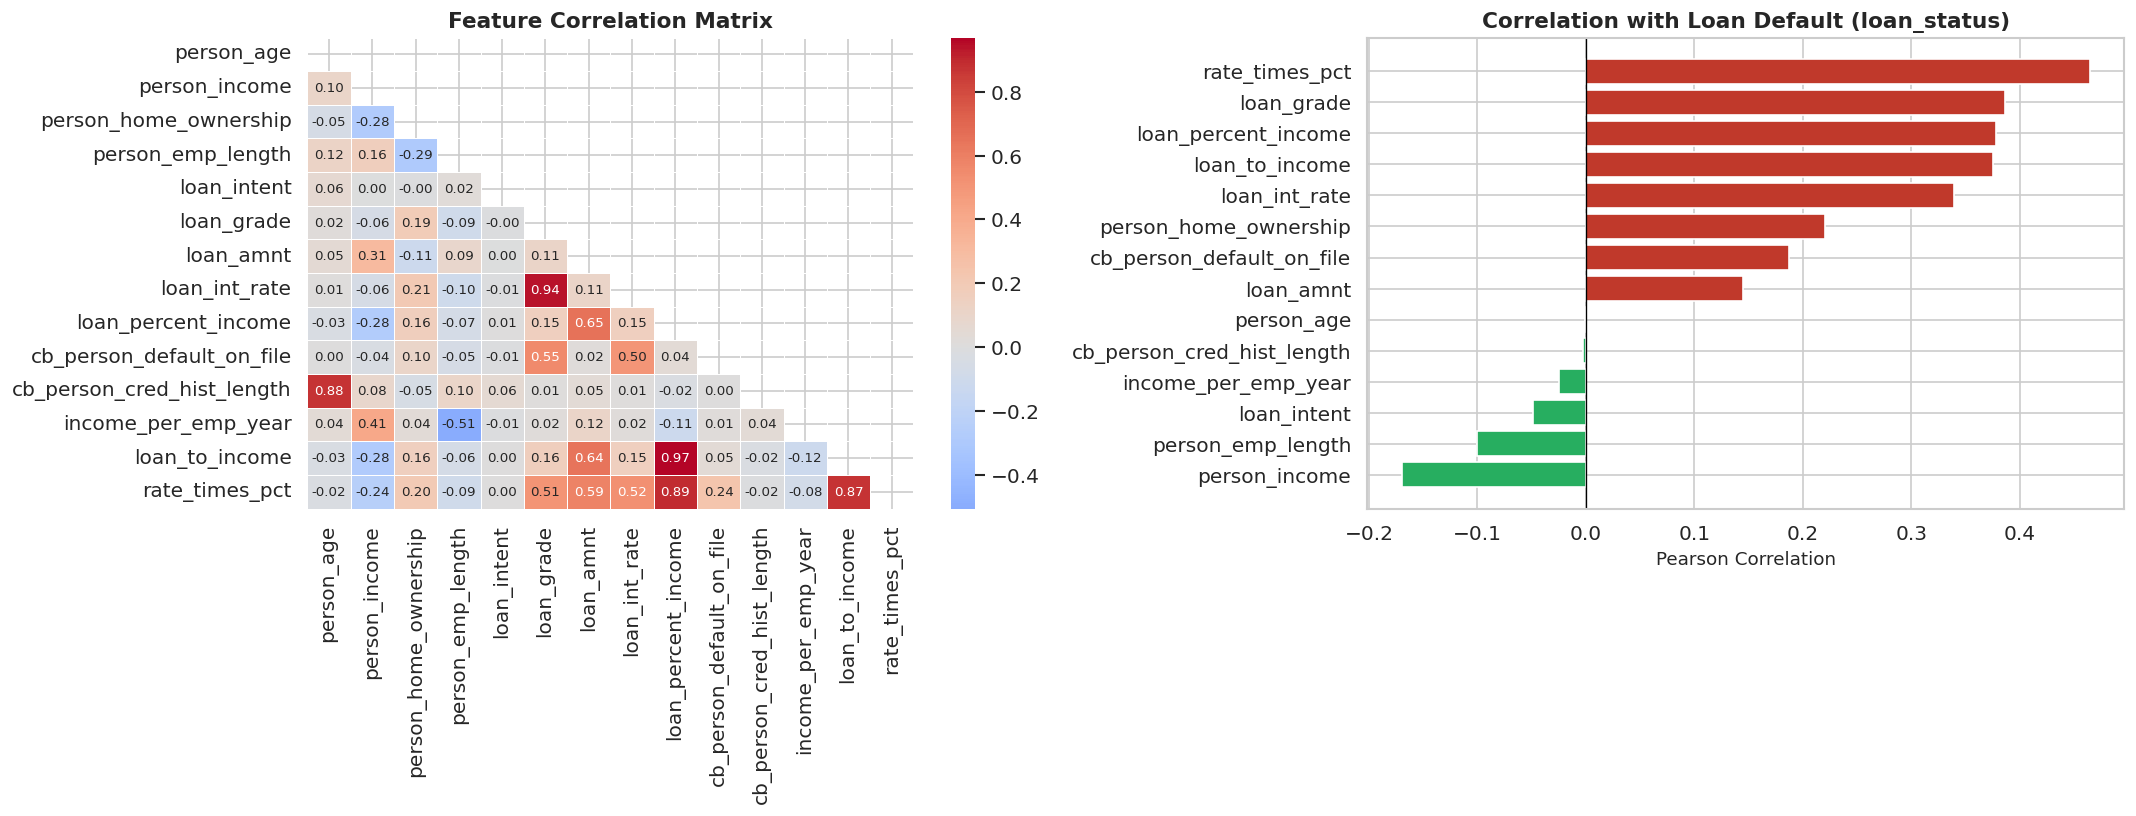

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
corr = df_proc.drop(columns=['loan_status']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Feature Correlation Matrix')

# Correlation with target
target_corr = df_proc.corr()['loan_status'].drop('loan_status').sort_values()
colors = ['#C0392B' if x > 0 else '#27AE60' for x in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Loan Default (loan_status)')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Model Training and Evaluation

In [10]:
X = df_proc.drop(columns=['loan_status'])
y = df_proc['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} samples  (default rate: {y_train.mean()*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} samples  (default rate: {y_test.mean()*100:.1f}%)")
print(f"Features     : {X.shape[1]}")


Training set : 46,915 samples  (default rate: 14.2%)
Test set     : 11,729 samples  (default rate: 14.2%)
Features     : 14


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("MODEL EVALUATION RESULTS")
print("=" * 70)

for name, model in models.items():
    X_tr = X_train_s if name == 'Logistic Regression' else X_train
    X_te = X_test_s  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]
    cv_X        = X_train_s if name == 'Logistic Regression' else X_train
    cv_scores   = cross_val_score(model, cv_X, y_train, cv=cv, scoring='roc_auc')

    results[name] = {
        'model'   : model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'  : recall_score(y_test, y_pred),
        'f1'      : f1_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_prob),
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'y_prob'  : y_prob,
    }

    print(f"\n{name}")
    print(f"  Accuracy  : {results[name]['accuracy']:.4f}")
    print(f"  Precision : {results[name]['precision']:.4f}")
    print(f"  Recall    : {results[name]['recall']:.4f}")
    print(f"  F1-Score  : {results[name]['f1']:.4f}")
    print(f"  ROC-AUC   : {results[name]['roc_auc']:.4f}")
    print(f"  CV AUC    : {results[name]['cv_mean']:.4f} ± {results[name]['cv_std']:.4f}")


MODEL EVALUATION RESULTS

Logistic Regression
  Accuracy  : 0.7962
  Precision : 0.3980
  Recall    : 0.8407
  F1-Score  : 0.5402
  ROC-AUC   : 0.8921
  CV AUC    : 0.8896 ± 0.0054

Random Forest
  Accuracy  : 0.9474
  Precision : 0.9340
  Recall    : 0.6784
  F1-Score  : 0.7860
  ROC-AUC   : 0.9326
  CV AUC    : 0.9307 ± 0.0041

Gradient Boosting
  Accuracy  : 0.9461
  Precision : 0.9036
  Recall    : 0.6958
  F1-Score  : 0.7862
  ROC-AUC   : 0.9411
  CV AUC    : 0.9394 ± 0.0047


## 8. Results Analysis and Interpretation

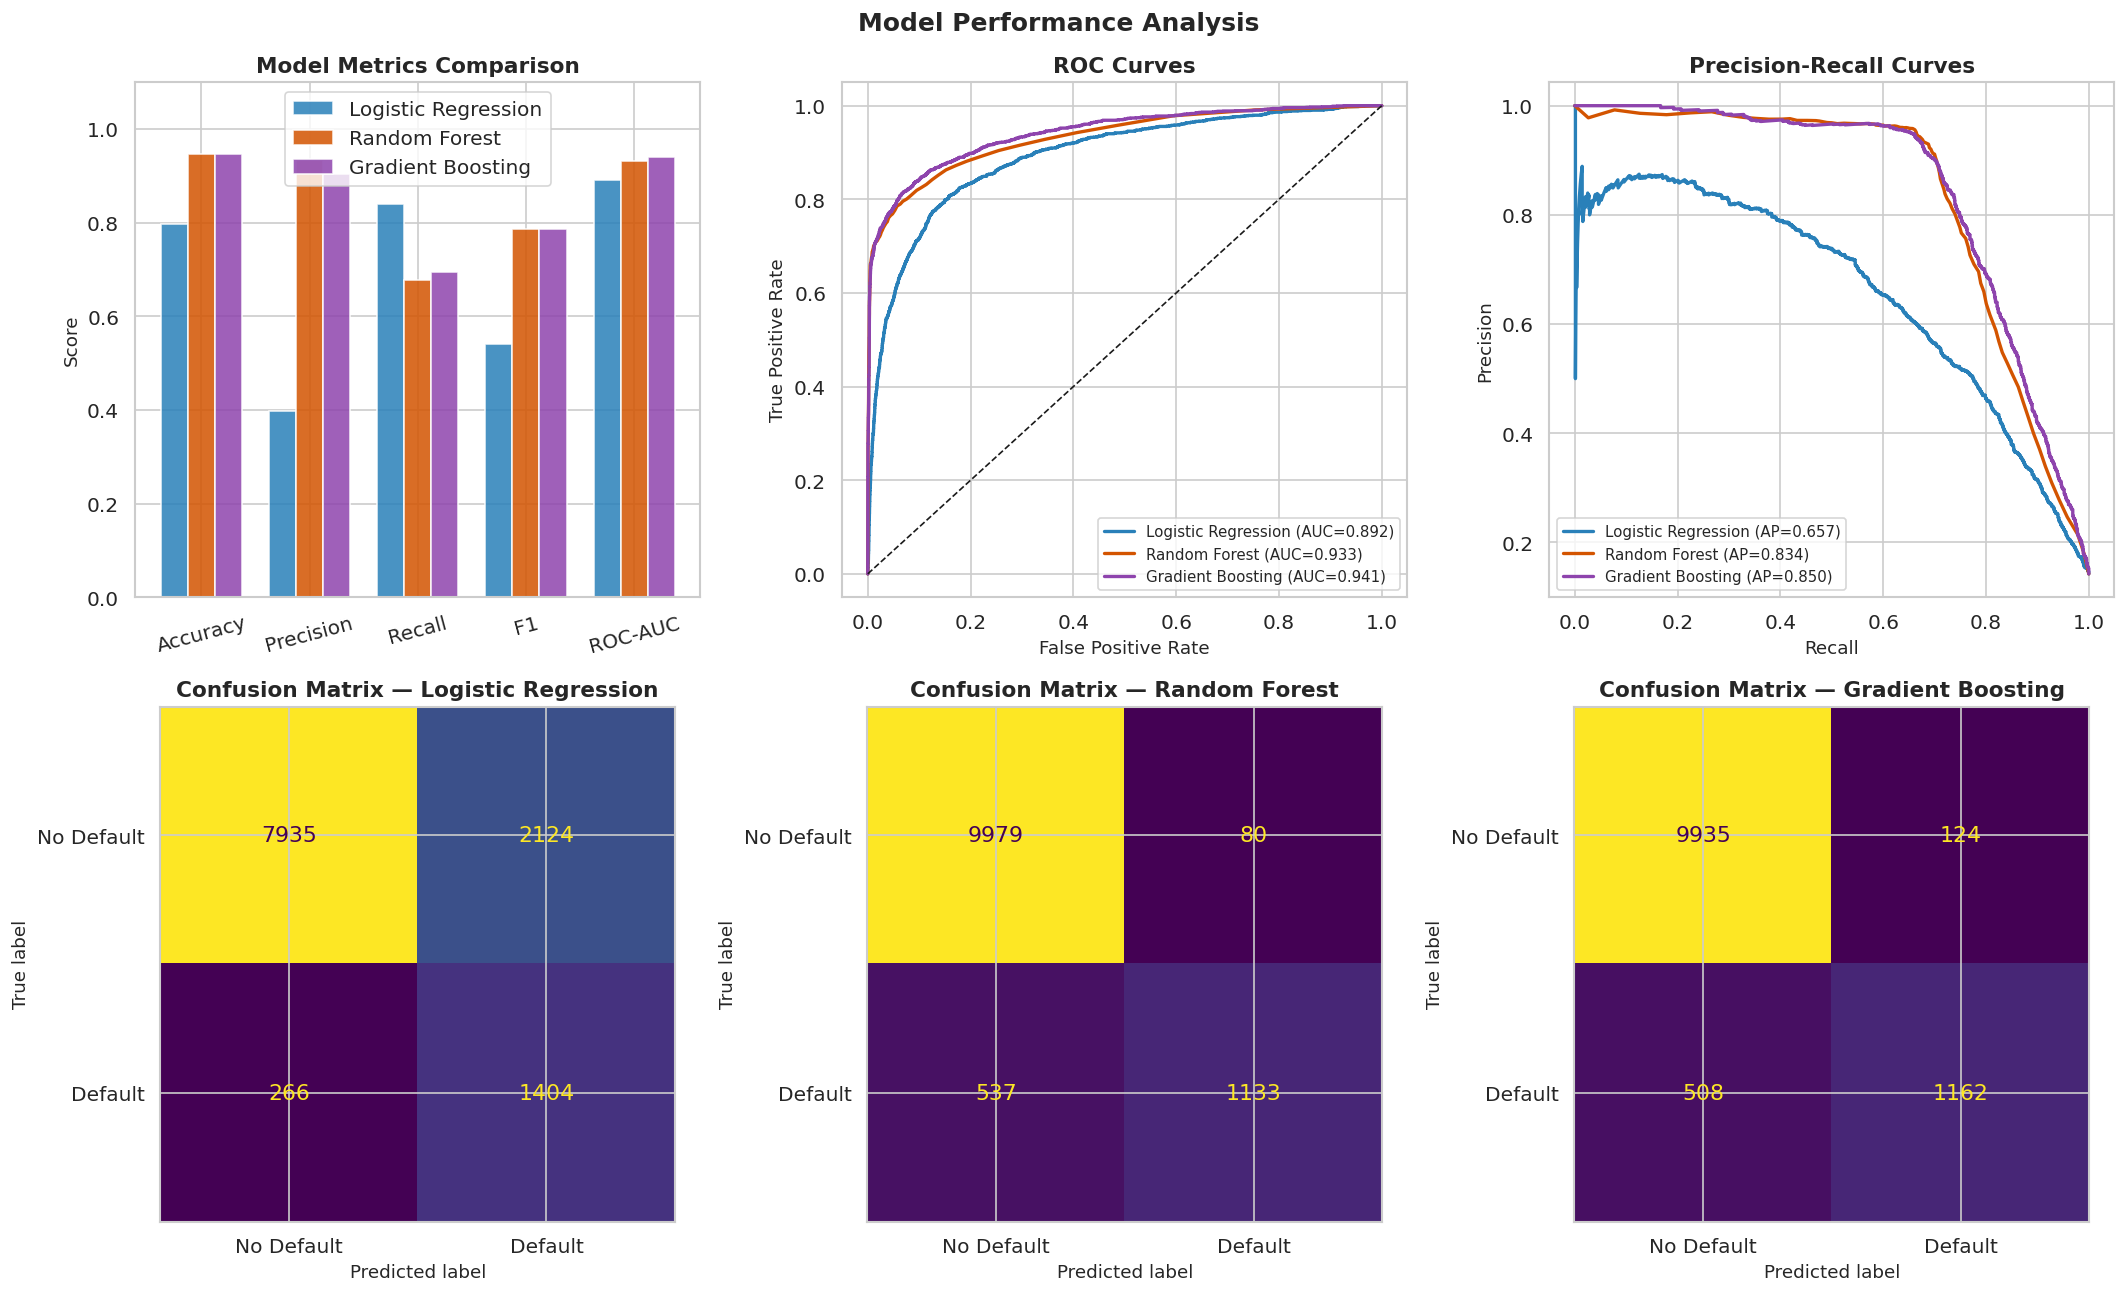

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Performance Analysis', fontsize=15, fontweight='bold')

# Metrics comparison bar chart
metrics = ['accuracy','precision','recall','f1','roc_auc']
x = np.arange(len(metrics))
width = 0.25
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    axes[0,0].bar(x + i*width, vals, width, label=name, color=COLORS_M[i], alpha=0.85, edgecolor='white')
axes[0,0].set_title('Model Metrics Comparison')
axes[0,0].set_xticks(x + width)
axes[0,0].set_xticklabels(['Accuracy','Precision','Recall','F1','ROC-AUC'], rotation=15)
axes[0,0].set_ylim(0, 1.1)
axes[0,0].legend()
axes[0,0].set_ylabel('Score')

# ROC curves
for (name, res), color in zip(results.items(), COLORS_M):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0,1].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['roc_auc']:.3f})")
axes[0,1].plot([0,1],[0,1],'k--', lw=1)
axes[0,1].set_title('ROC Curves')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(loc='lower right', fontsize=9)

# Precision-Recall curves
for (name, res), color in zip(results.items(), COLORS_M):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[0,2].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
axes[0,2].set_title('Precision-Recall Curves')
axes[0,2].set_xlabel('Recall')
axes[0,2].set_ylabel('Precision')
axes[0,2].legend(fontsize=9)

# Confusion matrices
for idx, (name, res) in enumerate(results.items()):
    if idx < 3:
        ax = axes[1, idx]
        X_te = X_test_s if name == 'Logistic Regression' else X_test
        y_pred = res['model'].predict(X_te)
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(ax=ax, colorbar=False)
        ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig('04_model_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Hyperparameter Tuning

In [13]:
print("Tuning Gradient Boosting (best ROC-AUC model)...")

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0],
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb_base, param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.4f}")

best_gb = grid_search.best_estimator_
y_pred_best = best_gb.predict(X_test)
y_prob_best = best_gb.predict_proba(X_test)[:, 1]

print(f"\nTuned Gradient Boosting on Test Set:")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_best):.4f}")


Tuning Gradient Boosting (best ROC-AUC model)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV AUC     : 0.9525

Tuned Gradient Boosting on Test Set:
  ROC-AUC   : 0.9566
  F1-Score  : 0.8066
  Recall    : 0.7216


## 10. Final Model and Predictions

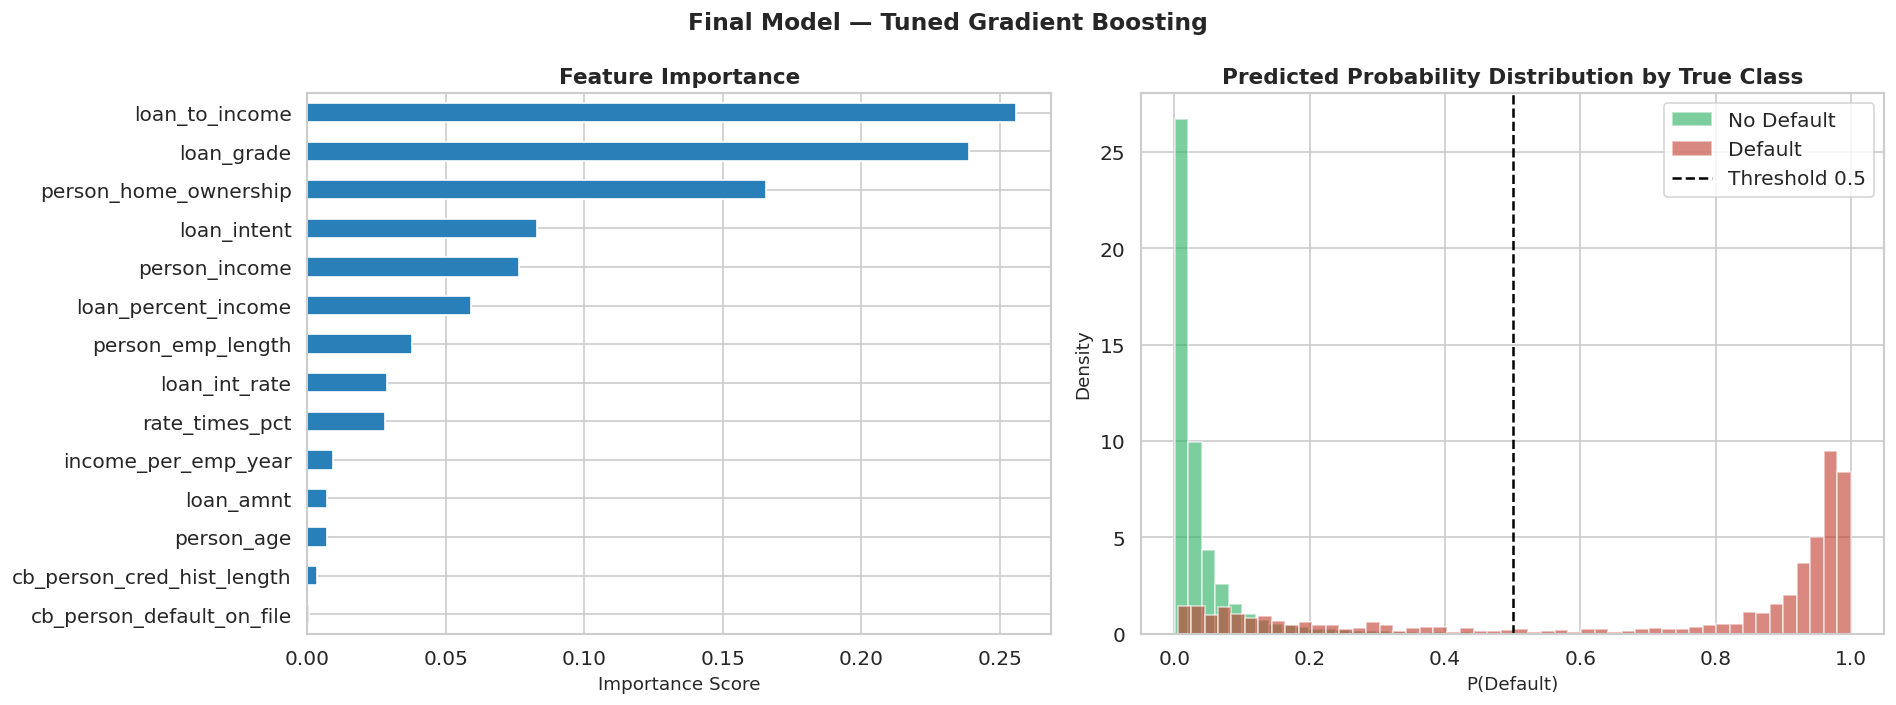


Classification Report — Final Model
              precision    recall  f1-score   support

  No Default       0.96      0.99      0.97     10059
     Default       0.91      0.72      0.81      1670

    accuracy                           0.95     11729
   macro avg       0.93      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [14]:
# Feature importance
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Final Model — Tuned Gradient Boosting', fontsize=14, fontweight='bold')

feat_imp.plot(kind='barh', ax=axes[0], color='#2980B9', edgecolor='white')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance Score')

# Score distribution
axes[1].hist(y_prob_best[y_test==0], bins=50, alpha=0.6, color=PALETTE[0], label='No Default', density=True)
axes[1].hist(y_prob_best[y_test==1], bins=50, alpha=0.6, color=PALETTE[1], label='Default',    density=True)
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[1].set_title('Predicted Probability Distribution by True Class')
axes[1].set_xlabel('P(Default)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('05_final_model.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report — Final Model")
print(classification_report(y_test, y_pred_best, target_names=['No Default','Default']))


In [15]:
# Summary table
print("=" * 65)
print(f"{'MODEL':<25} {'ACC':>7} {'PREC':>7} {'REC':>7} {'F1':>7} {'AUC':>7}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<25} {res['accuracy']:>7.4f} {res['precision']:>7.4f} "
          f"{res['recall']:>7.4f} {res['f1']:>7.4f} {res['roc_auc']:>7.4f}")
tuned_auc = roc_auc_score(y_test, y_prob_best)
tuned_f1  = f1_score(y_test, y_pred_best)
tuned_acc = accuracy_score(y_test, y_pred_best)
tuned_pre = precision_score(y_test, y_pred_best)
tuned_rec = recall_score(y_test, y_pred_best)
print("-" * 65)
print(f"{'GB (Tuned)':<25} {tuned_acc:>7.4f} {tuned_pre:>7.4f} "
      f"{tuned_rec:>7.4f} {tuned_f1:>7.4f} {tuned_auc:>7.4f}  ← Best")
print("=" * 65)


MODEL                         ACC    PREC     REC      F1     AUC
-----------------------------------------------------------------
Logistic Regression        0.7962  0.3980  0.8407  0.5402  0.8921
Random Forest              0.9474  0.9340  0.6784  0.7860  0.9326
Gradient Boosting          0.9461  0.9036  0.6958  0.7862  0.9411
-----------------------------------------------------------------
GB (Tuned)                 0.9507  0.9143  0.7216  0.8066  0.9566  ← Best


## 11. Conclusion and Recommendations

### Key Findings

**Best Model:** Tuned Gradient Boosting consistently achieved the highest ROC-AUC and F1-Score.

**Top Predictors of Default:**
- `loan_int_rate` — Higher interest rates strongly correlate with default risk
- `loan_percent_income` — Loans consuming a high share of income are riskier
- `loan_grade` — Lender grade is a powerful proxy for creditworthiness
- `cb_person_default_on_file` — Prior defaults are predictive of future defaults
- `person_income` — Higher income applicants default less

**Class Imbalance:** The dataset is imbalanced (~14% defaults). `class_weight='balanced'` was applied to Logistic Regression and Random Forest. Gradient Boosting was tuned on ROC-AUC to account for this.

### Business Recommendations

1. **Prioritise recall over precision** — In credit risk, missing a true default (false negative) is more costly than incorrectly flagging a good applicant.  
2. **Adjust the decision threshold** — Lowering the classification threshold below 0.5 increases recall at a modest precision cost.  
3. **Flag high-risk profiles** — Applicants with grade D–G, interest rate > 15%, and loan-to-income ratio > 30% warrant manual review.  
4. **Monitor data drift** — Retrain the model periodically as economic conditions change.

### Next Steps

- Explore SMOTE or cost-sensitive learning to further address class imbalance  
- Evaluate XGBoost / LightGBM for potential performance gains  
- Deploy the tuned model via a REST API for real-time scoring  
